In [5]:
%load_ext autoreload
%autoreload 2 
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import root_mean_squared_error
from Preprocess import preprocess_data
from xgboost import XGBRegressor
from xgboost.callback import EarlyStopping
from sklearn.metrics import mean_absolute_error
import optuna

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [6]:
data = pd.read_csv("../Whillians-GPS-Data-and-Features.csv")
X_train, X_val, X_test, y_train, y_val, y_test, feature_cols = preprocess_data(data)

In [7]:
# XGBoost


#Tuning XGBoost through the Optuna library
def objective(trial):
  XGBoost = XGBRegressor(
      objective="reg:squarederror",
      n_estimators=1000,
      learning_rate=trial.suggest_float("learning_rate", 0.01, 0.1, log=True), #sweeping 0.01 to 0.1 in the log scale for optimal learning rate
      max_depth=trial.suggest_int("max_depth",2,5), #checking max depth between 2 and 5
      subsample=trial.suggest_float("subsample",0.6,0.9), #sweeping subsample possibilites between 0.6 and 0.9
      colsample_bytree=trial.suggest_float("colsample_bytree",0.6,0.9), #sweeping bytree parameters between 0.6 and 0.9
      random_state=42
  )
  XGBoost.fit(
      X_train, y_train, eval_set=[(X_val, y_val)], verbose=False) #To see more model info set verbose=True
  predictions= XGBoost.predict(X_val)
  RMSE = root_mean_squared_error(y_val, predictions)
  return RMSE

optimization = optuna.create_study(direction="minimize") #Finding the parameters that minimize the MAE
optimization.optimize(objective, n_trials=30) #Keeping at 30 to prevent overfitting with noise

#Showing what the parameters are
optimal_params = optimization.best_params
print("Optimal Parameters:", optimal_params)

#Running the XGBoost with the optimal parameters
XGBoost = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=1000,
    **optimal_params,
    random_state=42,
)

XGBoost.fit(
    X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

#Calculating multiplicative error for XGBoost
XGBoost_Prediction = XGBoost.predict(X_test)
XGBoost_RMSE = root_mean_squared_error(y_test, XGBoost_Prediction)
XGBoost_Error = XGBoost_RMSE
print("XGBoost Error:", XGBoost_Error)

XGBoost_RMSE = mean_absolute_error(y_test, XGBoost_Prediction)
XGBoost_Error_MAE = XGBoost_RMSE
print("Mean XGBoost Error:", XGBoost_Error_MAE)

[I 2026-01-24 11:22:20,623] A new study created in memory with name: no-name-6035d9da-c558-4134-b1bb-904499ab2471
[I 2026-01-24 11:22:21,237] Trial 0 finished with value: 10691.798843713203 and parameters: {'learning_rate': 0.011423776146568471, 'max_depth': 3, 'subsample': 0.7441951958027547, 'colsample_bytree': 0.8969932910926771}. Best is trial 0 with value: 10691.798843713203.
[I 2026-01-24 11:22:21,787] Trial 1 finished with value: 10789.275194545315 and parameters: {'learning_rate': 0.013916620723735734, 'max_depth': 3, 'subsample': 0.8451352006121939, 'colsample_bytree': 0.732780609026996}. Best is trial 0 with value: 10691.798843713203.
[I 2026-01-24 11:22:22,366] Trial 2 finished with value: 10860.351362296326 and parameters: {'learning_rate': 0.08690060206707903, 'max_depth': 3, 'subsample': 0.8267187173542979, 'colsample_bytree': 0.6751396993203831}. Best is trial 0 with value: 10691.798843713203.
[I 2026-01-24 11:22:22,836] Trial 3 finished with value: 9042.106150735568 and

Optimal Parameters: {'learning_rate': 0.020404696944759566, 'max_depth': 5, 'subsample': 0.7960482026457496, 'colsample_bytree': 0.6544465258832195}
XGBoost Error: 3412.8822997233847
Mean XGBoost Error: 859.0247576912193


Sample0: True = 665.00s, Predicted = 810.03s, Error=145.03s
Sample1: True = 897.75s, Predicted = 884.47s, Error=13.28s
Sample2: True = 1377.25s, Predicted = 853.98s, Error=523.27s
Sample3: True = 1545.00s, Predicted = 863.14s, Error=681.86s
Sample4: True = 1230.00s, Predicted = 908.71s, Error=321.29s
Sample5: True = 803.75s, Predicted = 1010.15s, Error=206.40s
Sample6: True = 790.00s, Predicted = 1020.70s, Error=230.70s
Sample7: True = 1196.25s, Predicted = 1134.26s, Error=61.99s
Sample8: True = 920.00s, Predicted = 856.37s, Error=63.63s
Sample9: True = 715.00s, Predicted = 868.99s, Error=153.99s
Sample10: True = 1223.75s, Predicted = 1057.22s, Error=166.53s
Sample11: True = 1396.25s, Predicted = 902.32s, Error=493.93s
Sample12: True = 1448.75s, Predicted = 1028.89s, Error=419.86s
Sample13: True = 1446.25s, Predicted = 927.62s, Error=518.63s
Sample14: True = 1505.00s, Predicted = 1103.10s, Error=401.90s
Sample15: True = 615.00s, Predicted = 1157.64s, Error=542.64s
Sample16: True = 868.

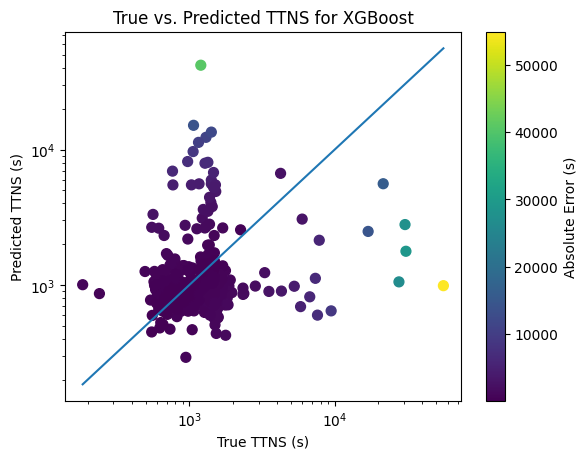

In [8]:
#XGBoost Analysis

#Taking the target column and predictions out of the log scale to calculate the average error in seconds
y_test_secs = y_test
XG_pred_secs = XGBoost_Prediction

absolute_error_secs_XG = np.abs(XG_pred_secs - y_test_secs)

#printing the true vs predicted value and error in seconds for every recrod
for i, (true, pred, abs_error) in enumerate(zip(y_test_secs, XG_pred_secs, absolute_error_secs_XG)):
  print(f"Sample{i}: True = {true:.2f}s, Predicted = {pred:.2f}s, Error={abs_error:.2f}s")

# Scatter plot of predicted vs true
plt.figure()
plt.scatter(y_test_secs, XG_pred_secs, c=absolute_error_secs_XG, cmap='viridis', s=50)
plt.colorbar(label="Absolute Error (s)")
plt.plot([min(y_test_secs), max(y_test_secs)], [min(y_test_secs), max(y_test_secs)])
plt.xlabel("True TTNS (s)")
plt.ylabel("Predicted TTNS (s)")
plt.title("True vs. Predicted TTNS for XGBoost")
plt.xscale('log')
plt.yscale('log')
plt.show()